In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import pandas as pd
import polars as pl
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from sklearn.cluster import DBSCAN, HDBSCAN, OPTICS
from sklearn.neighbors import KDTree
from sklearn.neighbors import NearestNeighbors

import sys

sys.path.append("../..")

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter(dark_background=False)

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from src import SpotDetectionFunctions

SD_F = SpotDetectionFunctions.SpotDetection_Functions()

from src import SR_Functions

SRes_F = SR_Functions.SuperRes_Functions()

from src import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

from src import render
from src import postprocess as _postprocess
from src import FiducialDetection

FD = FiducialDetection.FiducialDetector()


import types

import DriftCorrectionFunctions as DCF
from src.LinkingFunctions import link_localisations


smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

INFO:Constants:Logging to file: /home/jsb92/Documents/pyBayerSMLM/logs/Constants_20260405_131542.log
/tmp/ipykernel_2017782/2743527195.py:29: DeprecationWarning: PlottingFunctions.Plotter is deprecated and will be removed in a future version. Use PlottingBase.PublicationPlotter directly instead.
  plotter = PlottingFunctions.Plotter(dark_background=False)


In [2]:
data_folder = "../../Camera_Calibrations/Ximea_Camera"
gain_map = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset_map = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
read_noise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()

pixel_QYs = np.vstack([B, G, R])
camera_parameters = {}
camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ["B", "G", "R"]
camera_parameters["pixel_order_indices"] = [0, 1, 2]

In [3]:
image_folder = "/scratch/sycamore-asap/2026_Multicolour_Paper/Data/Ximea/SAureus/PLL_1in10_Condition1/50ms_70p_515_LP515_bp650_200_2"

In [4]:
localisation_files = H_F.file_search(image_folder, ".h5", "")

In [5]:
localisation_files

['/scratch/sycamore-asap/2026_Multicolour_Paper/Data/Ximea/SAureus/PLL_1in10_Condition1/50ms_70p_515_LP515_bp650_200_2/Localisations.h5',
 '/scratch/sycamore-asap/2026_Multicolour_Paper/Data/Ximea/SAureus/PLL_1in10_Condition1/50ms_70p_515_LP515_bp650_200_2/Localisations_Undrifted_Linked.h5',
 '/scratch/sycamore-asap/2026_Multicolour_Paper/Data/Ximea/SAureus/PLL_1in10_Condition1/50ms_70p_515_LP515_bp650_200_2/Localisations_Undrifted_Linked_averagedoverclusters.h5',
 '/scratch/sycamore-asap/2026_Multicolour_Paper/Data/Ximea/SAureus/PLL_1in10_Condition1/50ms_70p_515_LP515_bp650_200_2/Localisations_Undrifted_Linked_clusteredlocs.h5']

In [10]:
tif_files = H_F.file_search(image_folder, ".tif", "")

In [11]:
metadata_files = H_F.file_search(image_folder, "metadata", "")

In [12]:
x_coord, y_coord, width, height = IO.metadata_reader_imageJ(metadata_files[0])
n_frames = IO.metadata_nframes_reader_imageJ(metadata_files[0])

In [9]:
loc_data = pd.read_hdf(localisation_files[0])

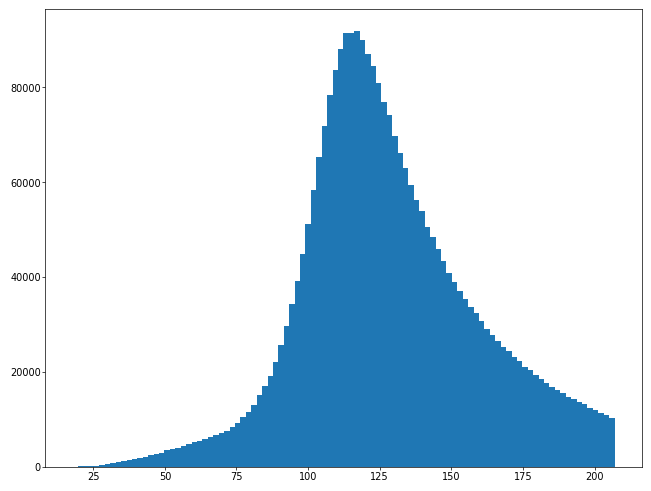

In [13]:
plt.hist(loc_data['s_x']*69, 100);
plt.show()

In [14]:
loc_data = loc_data[loc_data["xc_err"] < 50/69]
loc_data = loc_data[loc_data["yc_err"] < 50/69]

loc_data = loc_data[loc_data["xc_err"] > 0]
loc_data = loc_data[loc_data["yc_err"] > 0]

loc_data = loc_data[loc_data["s_x_err"] < 50/69]
loc_data = loc_data[loc_data["s_y_err"] < 50/69]

loc_data = loc_data[(loc_data["s_x"] > 100/69) & (loc_data["s_x"] < 175/69)]
loc_data = loc_data[(loc_data["s_y"] > 100/69) & (loc_data["s_y"] < 175/69)]

loc_data = loc_data[loc_data["A_B_err"] < 0.01]
loc_data = loc_data[loc_data["A_G_err"] < 0.01]
loc_data = loc_data[loc_data["A_R_err"] < 0.01]

loc_data = loc_data[loc_data["A_B"] > 0.005]
loc_data = loc_data[loc_data["A_G"] > 0.05]
loc_data = loc_data[loc_data["A_R"] > 0.5]

loc_data = loc_data[loc_data["bg_B_err"] < 0.15]
loc_data = loc_data[loc_data["bg_G_err"] < 0.15]
loc_data = loc_data[loc_data["bg_R_err"] < 0.15]

loc_data = loc_data[~((loc_data['spot_snr'] < 2) & (loc_data['photons'] < 500) & (loc_data['spot_matched_filter_response'] < 100))]

loc_data = loc_data[loc_data["spot_background_std"] > 10]

#loc_data = loc_data[loc_data["photons"] < 100000]
#loc_data = loc_data[loc_data["photons"] > 100]


loc_data = loc_data[loc_data["chi_sqr"] < 1.5]

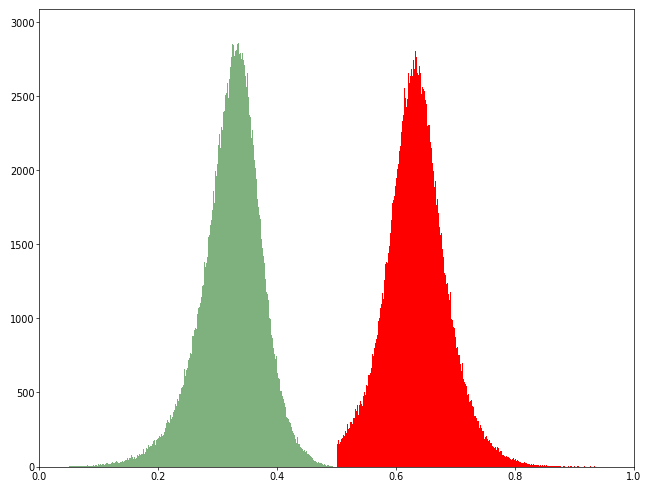

In [15]:
plt.hist(loc_data['A_R'], 1000, color='red');
plt.hist(loc_data['A_G'], 1000, alpha=0.5, color='darkgreen');
#plt.hist(loc_data['A_B'], 1000, alpha=0.5, color='lightblue');
plt.xlim([0, 1])
plt.show()

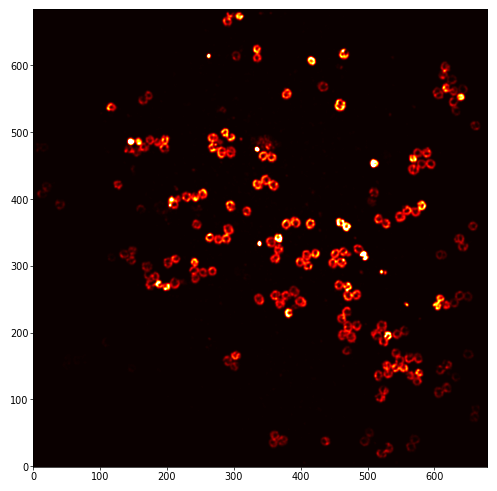

In [19]:
image = render.render(
    locs=loc_data.to_records(index=False),
    oversampling=1,
    viewport=((0, 0), (height, width)),
    blur_method="smooth",
)[1]

plt.imshow(image, origin='lower', cmap='hot', vmax=np.percentile(image, 99.9))

In [22]:
drift_corrector = DCF.Drift_Correction_Functions()

info = [{
    "Width": width,         # Image width in pixels
    "Height": height,        # Image height in pixels
    "Frames": np.max(loc_data['frame']),      # Total number of frames in the movie
    "Pixelsize": 69,        # pixel size always in nm
}]

corrected_locs, drift_result = drift_corrector.undrift(locs=loc_data.to_records(index=False),
                                          info=info,
                                          method="aim",
                                          segmentation=50,
                                            intersect_d=20/69,
                                          roi_r=60/69,
                                         )
corrected_locs = pd.DataFrame(corrected_locs)

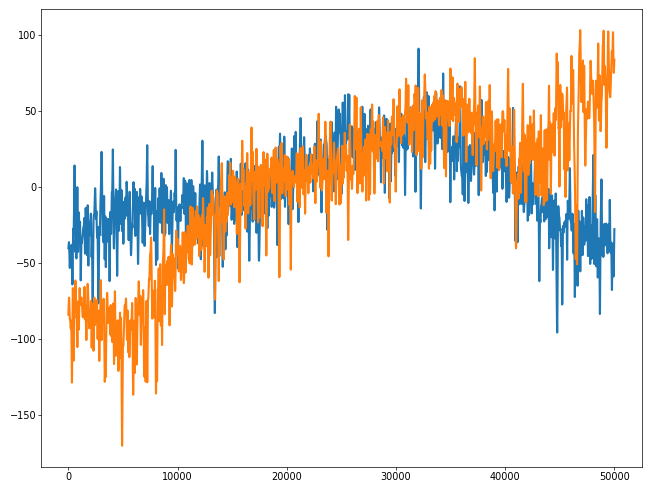

In [23]:
plt.plot(drift_result.drift_x*69)
plt.plot(drift_result.drift_y*69)

plt.show()

In [24]:
link_r = 0.5 * (np.median(corrected_locs['xc_err']) + np.median(corrected_locs['yc_err']))
linked = link_localisations(corrected_locs, n_frames=n_frames, r_max=link_r, max_dark_time=2)

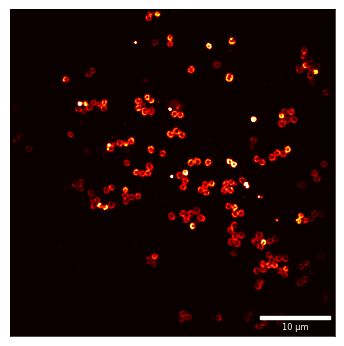

In [28]:
oversampling = 1

info = [{
    "Width": width,         # Image width in pixels
    "Height": height,        # Image height in pixels
    "Frames": np.max(loc_data['frame']),      # Total number of frames in the movie
    "Pixelsize": 69,        # pixel size always in nm
}]

image = render.render(
            locs=linked.to_records(index=False),
            info=info,
            blur_method="smooth",
            oversampling=oversampling
        )[1]  # Take the rendered image

fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(axs, image, cmap='hot', vmax=np.percentile(image, 99.9), cbar='off')

In [30]:
IO._write_h5_database(df=linked, filepath=localisation_files[0].split('.h5')[0]+'_Undrifted_Linked.h5', normalise_photons=False)

In [6]:
localisation_files

['/scratch/sycamore-asap/2026_Multicolour_Paper/Data/Ximea/SAureus/PLL_1in10_Condition1/50ms_70p_515_LP515_bp650_200_2/Localisations.h5',
 '/scratch/sycamore-asap/2026_Multicolour_Paper/Data/Ximea/SAureus/PLL_1in10_Condition1/50ms_70p_515_LP515_bp650_200_2/Localisations_Undrifted_Linked.h5',
 '/scratch/sycamore-asap/2026_Multicolour_Paper/Data/Ximea/SAureus/PLL_1in10_Condition1/50ms_70p_515_LP515_bp650_200_2/Localisations_Undrifted_Linked_averagedoverclusters.h5',
 '/scratch/sycamore-asap/2026_Multicolour_Paper/Data/Ximea/SAureus/PLL_1in10_Condition1/50ms_70p_515_LP515_bp650_200_2/Localisations_Undrifted_Linked_clusteredlocs.h5']

In [7]:
linked = pd.read_hdf(localisation_files[1])

In [13]:
oversampling = 8
min_blur_width = 4*0.069
info = [{
    "Width": width,         # Image width in pixels
    "Height": height,        # Image height in pixels
    "Frames": np.max(linked['frame']),      # Total number of frames in the movie
    "Pixelsize": 69,        # pixel size always in nm
}]

image = render.render(
            locs=linked.to_records(index=False),
            info=info,
            blur_method="smooth",
            oversampling=oversampling,
            min_blur_width=min_blur_width
        )[1]  # Take the rendered image

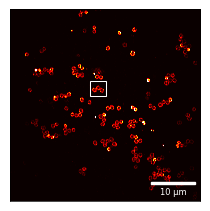

In [17]:
fig, axs = plotter.two_column_plot(height=2, width=2)

cut = image[500:, 500:]
axs = plotter.image_plot(axs, cut, cmap='hot', cbar='off', vmax=np.percentile(image, 99.9), pixelsize=69/oversampling)


import matplotlib.patches as patches

rect = patches.Rectangle(
    ((260 * oversampling), (340 * oversampling)),
    50 * oversampling,
    50 * oversampling,
    linewidth=0.75,
    edgecolor="white",
    facecolor="none",
)

# Add the patch to the Axes
axs.add_patch(rect)


folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks'
plt.savefig(os.path.join(folder, "Image_SAureus.svg"), dpi=600, format="svg")
plt.show()

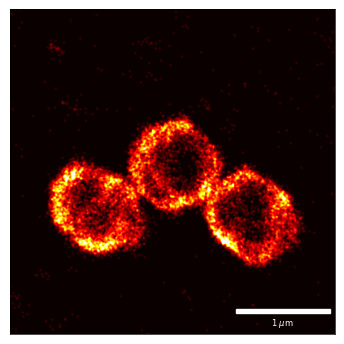

In [16]:
fig, axs = plotter.one_column_plot()

data = cut[
        int(340 * oversampling) : int(340 * oversampling) + int(50 * oversampling),
        int(260) * oversampling : int(260) * oversampling + int(50 * oversampling),
    ]

axs = plotter.image_plot(
    axs=axs,
    data=data,
    vmin=np.percentile(cut, 1),
    vmax=np.percentile(cut, 99.9),
    cbar="off",
    cbarlabel="localisations",
    pixelsize=69 / oversampling,
    scalebarsize=1000,
    scalebarlabel=r"1 $\mu$m",
    cmap="hot",
)

folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks'
plt.savefig(os.path.join(folder, "SAureus_Zoomin.svg"), dpi=600, format="svg")
plt.show()

In [26]:
linked.columns

Index(['frame', 'xc', 'yc', 'xc_err', 'yc_err', 'photons', 'bg_B', 'bg_G',
       'bg_R', 'A_B', 'A_B_err', 'A_G', 'A_G_err', 'A_R', 'A_R_err', 's_x',
       's_x_err', 's_y', 's_y_err', 'chi_sqr', 'bg_B_err', 'bg_G_err',
       'bg_R_err', 'spot_matched_filter_response', 'spot_background',
       'spot_background_std', 'spot_mean_inner_intensity',
       'spot_fraction_above_threshold', 'spot_n_pixels_above_threshold',
       'spot_snr', 'background_photons', 'len', 'n', 'photon_rate'],
      dtype='object')

Step 1/5: Rendering super-resolved image...
Step 2/5: Applying li thresholding...
Step 3/5: Detecting connected regions...
Step 4/5: Filtering aggregates by size and localisation count...


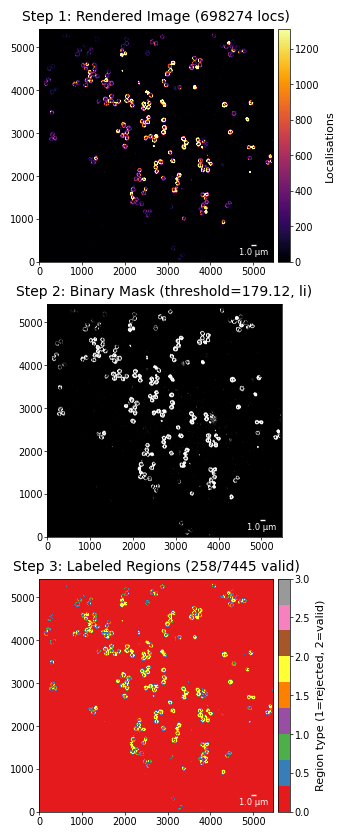

Found 258 valid aggregates (from 7445 total regions)
Step 5/5: Extracting localisations and computing statistics...
✓ Complete! Extracted 644355 localisations in 258 aggregates                    9.13it/s]


In [27]:
# Define parameters
MIN_AREA_NM2 = 100.0  # Minimum area threshold in nm² (50000 nm² = 0.05 µm²)
MIN_LOCS = 20      # Minimum localisations per cluster
PIXEL_SIZE_NM = 69.0  # Camera pixel size in nanometers
OVERSAMPLING = 8      # Super-resolution rendering oversampling


file = localisation_files[1]
# Run memory-efficient segmentation
# This uses image thresholding instead of DBSCAN - MUCH more memory efficient!
bacteria_locs, per_bacteria_stats = _postprocess.segment_locs_by_rendered_image(
    linked,
    width=width,
    height=height,
    oversampling=OVERSAMPLING,
    pixel_size_nm=PIXEL_SIZE_NM,
    min_area_nm2=MIN_AREA_NM2,
    min_localisations=MIN_LOCS,
    threshold_method='li',  # Li thresholding works well for bacterial imaging
    callback='console',
    blur_method='gaussian',
    verbose=True,
)

# Rename columns to match expected output format
bacteria_locs = bacteria_locs.rename(
    columns={'aggregate_id': 'cluster_id', 'aggregate_area_nm2': 'cluster_area_nm2'}
)
per_bacteria_stats = per_bacteria_stats.rename(
    columns={'aggregate_id': 'cluster_id'}
)

# Save results (same file names as before)
IO._write_h5_database(
    df=bacteria_locs,
    filepath=file.split('.h5')[0] + '_clusteredlocs.h5',
    append=False,
    normalise_photons=False
)

IO._write_h5_database(
    df=per_bacteria_stats,
    filepath=file.split('.h5')[0] + '_averagedoverclusters.h5',
    append=False,
    normalise_photons=False
)

In [18]:
analysis_files = H_F.file_search(image_folder, "_clusteredlocs.h5", "")
print(analysis_files)

['/scratch/sycamore-asap/2026_Multicolour_Paper/Data/Ximea/SAureus/PLL_1in10_Condition1/50ms_70p_515_LP515_bp650_200_2/Localisations_Undrifted_Linked_clusteredlocs.h5']


In [35]:
import NileRedFunctions
import SpectralFunctions

# Initialize
nrf = NileRedFunctions.NileRed_Functions()

# Define optical setup
filters = [
  "semrock-ff01-650-200",
  "semrock-di03-r514-t1-25x36",
  "semrock-ff01-515-lp",
]

# Setup camera parameters
sf = SpectralFunctions.Spectral_Funcs()
R, G, B, wavelength = sf.getpixelefficiency()
pixel_QYs = np.vstack([B, G, R])

camera_params = {
  'pixel_QYs': pixel_QYs,
  'wavelength': wavelength,
}

analysis_files = H_F.file_search(image_folder, "_clusteredlocs.h5", "")

MIN_LOCS_ANALYSIS = 10      # Minimum localisations per wl fit

for file in analysis_files:
    # Fit wavelengths from HDF5 file
    # should now average and use average as initial guess
    df_with_wavelengths, grid_info = nrf.fit_wavelengths_pixelated(
      h5_path=file,
      filter_names=filters,
      camera_parameters=camera_params,
      output_path=file,
      min_localisations=MIN_LOCS_ANALYSIS,
      pixel_size_nm=50,
      aggregate_id_column='cluster_id',
    )


Pixelated Nile Red Wavelength Fitting
Input file: /scratch/sycamore-asap/2026_Multicolour_Paper/Data/Ximea/SAureus/PLL_1in10_Condition1/50ms_70p_515_LP515_bp650_200_2/Localisations_Undrifted_Linked_clusteredlocs.h5
Grid pixel size: 50 nm
Min localisations per pixel: 10
Wavelength bounds: 500.0-750.0 nm

Loaded 644355 localisations
Optical system configured with 3 filters
Using photon counts for SNR-based error inflation

--- Fitting aggregate-level wavelengths ---
Grouping by 'cluster_id'...
Found 258 aggregates
Aggregate fitting: 258 tasks with 28 workers...
  Aggregate fitting progress: 258/258 (100.0%) - 269.7 fits/s
  Aggregate fitting complete: 258/258 in 1.0 s
  Aggregate wavelength range: 606.5 - 640.4 nm
  Median: 619.0 nm
  Fitted: 258/258 aggregates
Grid dimensions: 914 x 920 pixels (45700 x 46000 nm)

Pixel groups: 43088 total
  Fitting: 22753 pixels (>= 10 localisations)
  Skipped: 20335 pixels (< 10 localisations)
  Locs/pixel: median 19, range [10-565]
Pixel fitting: 227

In [19]:
df_with_wavelengths = pd.read_hdf(analysis_files[0])

In [44]:
oversampling=8

n_locs, image_FOV, image_FOV_colour = render.render(
    locs=df_with_wavelengths.to_records(index=False),
    oversampling=oversampling,
    viewport=((0, 0), (np.max(df_with_wavelengths['yc']), np.max(df_with_wavelengths['xc']))),
    blur_method="gaussian_colour",
    cparam='wl_pixel',
    c_min=np.percentile(df_with_wavelengths['wl_pixel'], 5),
    c_max=np.percentile(df_with_wavelengths['wl_pixel'], 95),
)


In [45]:
from matplotlib import colors as mcolors

In [46]:
from copy import copy

In [47]:
image_total = copy(image_FOV)
vmax = np.percentile(image_total, 99.5)  # ignore empty pixels
vmin = np.percentile(image_total, 1)                                                                                                                                                                                                                                                  

new_brightness = np.clip((image_total - vmin) / (vmax - vmin), 0, 1)                                                                                                                                                                                           
                                                        
hsv = mcolors.rgb_to_hsv(image_FOV_colour)                                                                                                                                                                                                                         
hsv[..., 2] = new_brightness                              
image_adjusted = mcolors.hsv_to_rgb(hsv)

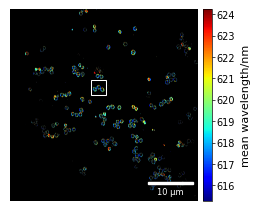

In [48]:
fig, axs = plotter.two_column_plot(height=2, width=2.25)

cut = image_adjusted[500:, 500:, :]
axs = plotter.colour_image_plot(axs, cut, cbar="on", cbarlabel=r'mean wavelength/nm', cmap="jet",
                            c_min=np.percentile(df_with_wavelengths['wl_pixel'], 5),
                            c_max=np.percentile(df_with_wavelengths['wl_pixel'], 95),
                            pixelsize=69/oversampling)

import matplotlib.patches as patches

rect = patches.Rectangle(
    ((260 * oversampling), (340 * oversampling)),
    50 * oversampling,
    50 * oversampling,
    linewidth=0.75,
    edgecolor="white",
    facecolor="none",
)

# Add the patch to the Axes
axs.add_patch(rect)


folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks'
plt.savefig(os.path.join(folder, "Image_SAureus_Wavelength.svg"), dpi=600, format="svg")
plt.show()

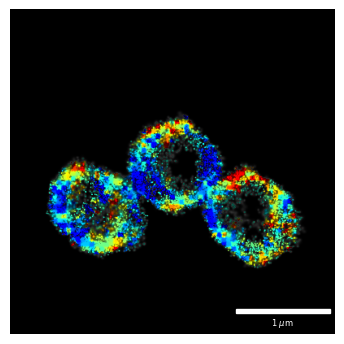

In [49]:
fig, axs = plotter.one_column_plot()

cut = image_adjusted[500:, 500:, :]
data = cut[
        int(340 * oversampling) : int(340 * oversampling) + int(50 * oversampling),
        int(260) * oversampling : int(260) * oversampling + int(50 * oversampling),
        :
    ]

axs = plotter.colour_image_plot(
    axs=axs,
    data=data,
    cbar='off',
    cbarlabel="localisations",
    pixelsize=69 / oversampling,
    scalebarsize=1000,
    scalebarlabel=r"1 $\mu$m",
)

folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks'
plt.savefig(os.path.join(folder, "SAureus_Zoomin_Colour.svg"), dpi=600, format="svg")
plt.show()

In [ ]:
def get_region_localisations(df, rectangles):
    """
    Filter localisations within each rectangle.

    Parameters
    ----------
    df : DataFrame
        Localisation table with 'xc', 'yc' in camera pixels.
    rectangles : list of dict
        Each dict: x0, y0, w, h in camera pixels; color and label are optional.

    Returns
    -------
    list of DataFrame, one per rectangle (same order as input).
    """
    regions = []
    for rect in rectangles:
        mask = (
            (df['xc'] >= rect['x0'])              &
            (df['xc'] <  rect['x0'] + rect['w']) &
            (df['yc'] >= rect['y0'])              &
            (df['yc'] <  rect['y0'] + rect['h'])
        )
        regions.append(df[mask].copy())
    return regions


In [ ]:
rects = [
    dict(x0=328, y0=408, w=12, h=12, label='Region A'),
    dict(x0=344, y0=425, w=12, h=12, label='Region B'),
]

region_A, region_B = get_region_localisations(df_with_wavelengths, rects)
print(f"Region A: {len(region_A)} localisations")
print(f"Region B: {len(region_B)} localisations")


In [8]:
averaged = df_with_wavelengths.groupby('pixel_ix', as_index=False).agg(                                                                                                                                                                                                         
      xc       = ('xc',      'mean'),                                                                                                                                                                                                                          
      yc       = ('yc',      'mean'),                                                                                                                                                                                                                            
      A_R      = ('A_R',     'mean'),                                                                                                                                                                                                                            
      A_G      = ('A_G',     'mean'),                                                                                                                                                                                                                            
      A_B      = ('A_B',     'mean'),                                                                                                                                                                                                                            
      photons  = ('photons', 'sum'),  
      wl_pixel = ('wl_pixel', 'mean'),
      n_locs   = ('frame',   'count'),   # number of localisations per pixel                                                                                                                                                                                     
  )

In [9]:
averaged['log_photons'] = np.log10(averaged['photons'])


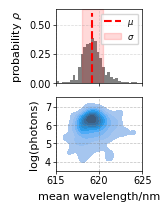

In [13]:
import seaborn as sns

fig, axs = plotter.one_column_plot(width=1.5, height=2, npanels=2, ratios=[1,1])

axs[0] = plotter.histogram_plot(axs[0], averaged['wl_pixel'], bins=np.histogram_bin_edges(averaged['wl_pixel'], 'fd'),
                               xaxislabel='')
mean=np.mean(averaged['wl_pixel'])
axs[0].vlines(x=mean, ymin=0, ymax=0.6, ls='--', color='red', label=r'$\mu$')

std=np.std(averaged['wl_pixel'])
axs[0].axvspan(mean - std, mean + std, alpha=0.15, color='red', label=r'$\sigma$')

axs[0].set_ylabel(r'probability $\rho$')
axs[0].set_xticklabels([])
axs[0].legend(fontsize=6)
axs[1].grid(True, lw=0.5, alpha=0.5, ls='--', color='grey')

sns.kdeplot(data=averaged, x="wl_pixel", y="log_photons", ax=axs[1], fill=True)
axs[1].set_xlabel('mean wavelength/nm')
axs[1].set_ylabel('log(photons)')
axs[1].set_ylim([3.5, 7.5])
axs[1].set_yticks([4, 5, 6, 7])
axs[1].set_xlim([615, 625])
axs[0].set_xlim([615, 625])

folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks'
plt.savefig(os.path.join(folder, "SAureus_Analysis_Wavelength.svg"), dpi=600, format="svg")
plt.show()

In [48]:
np.mean(averaged['wl_pixel'])

619.24994482625755

In [49]:
np.nanstd(averaged['wl_pixel'])

1.2577634767109238

In [ ]:
from src.FRCFunctions import fire

In [ ]:
# --- parameters ---
pixel_size_nm = 69      # nm per camera pixel
zoom          = 8      # SR pixels per camera pixel → 6.9 nm SR pixels

# linked_fremoved, width, height already defined in the notebook

# Shift localisations to start from (0,0) within their bounding box                                                                                                                                                                                            
red_xy = linked[['xc', 'yc']].to_numpy()                                                                                                                                                                                                                    
                                                                                                                                                                                                                                                             
x_min, y_min = red_xy[:, 0].min(), red_xy[:, 1].min()     
red_xy_shifted = red_xy.copy()                                                                                                                                                                                                                                 
red_xy_shifted[:, 0] -= x_min                                                                                                                                                                                                                                  
red_xy_shifted[:, 1] -= y_min
                                                                                                                                                                                                                                                             
nx_eff_red = int(red_xy[:, 0].max() - x_min) + 1                                                                                                                                                                                                                   
ny_eff_red = int(red_xy[:, 1].max() - y_min) + 1                                                                                                                                                                                                                   
print(f"Effective field: {nx_eff_red} × {ny_eff_red} px  ({nx_eff_red*69:.0f} × {ny_eff_red*69:.0f} nm)")                                                                                                                                                                      
                                                                                                                                                                                                                                                             
resolution_nm_655, frc_mean_655, res_hi_nm_655, res_lo_nm_655 = fire(                                                                                                                                                                                          
  positions     = red_xy_shifted,                                                                                                                                                                                                                            
  nx            = nx_eff_red,                                                                                                                                                                                                                                    
  ny            = ny_eff_red,                                                                                                                                                                                                                                    
  zoom          = zoom,
  n_blocks      = 50,                                                                                                                                                                                                                                        
  pixel_size_nm = pixel_size_nm,                                                                                                                                                                                                                             
)                                                                                                                                                                                                                                                              
print(f"FIRE resolution: {resolution_nm_655:.1f} nm")                                                                                                                                                                                                          

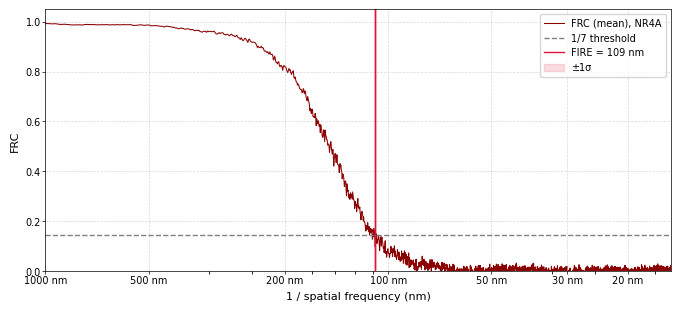

In [49]:
fig, ax = plotter.two_column_plot()

sz_red       = max(nx_eff_red, ny_eff_red) * zoom

sr_px_nm = pixel_size_nm / zoom        # nm per SR pixel

k_red   = np.arange(len(frc_mean_655))
q_red   = k_red / sz_red                           # cycles per SR pixel
q_nm_red = q_red / sr_px_nm                   # cycles per nm  (= 1 / d_nm)

# keep only below Nyquist
mask_red = (q_red > 0) & (q_red < 0.6)

# 1/7 crossing in cycles/nm
q_cross_655 = 1.0 / resolution_nm_655         # cycles per nm at the FIRE value
q_hi_655    = 1.0 / res_hi_nm_655
q_lo_655    = 1.0 / res_lo_nm_655

ax = plotter.line_plot(ax, q_nm_red[mask_red], frc_mean_655[mask_red], label='FRC (mean), NR4A', color='darkred')

ax.axhline(1/7, color='gray', ls='--', lw=1, label='1/7 threshold')
ax.axvline(q_cross_655, color='crimson', ls='-', lw=1,
           label=f'FIRE = {resolution_nm_655:.0f} nm')
ax.axvspan(q_lo_655, q_hi_655, alpha=0.15, color='crimson', label='±1σ')

ax.set_xlabel(r'1 / spatial frequency (nm)', fontsize=8)
ax.set_ylabel('FRC', fontsize=8)
ax.set_ylim([0, 1.05])
ax.set_xscale('log')

tick_nm = [1000, 500, 200, 100, 50, 30, 20]          # nm values to label
ax.set_xticks([1/d for d in tick_nm])

ax.set_xticklabels([f'{d} nm' for d in tick_nm])
ax.set_xlim(1/1000, 1/15)
ax.legend(fontsize=7)

folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks'
plt.savefig(os.path.join(folder, "FRC_SAureus.svg"), dpi=600, format="svg")
